<a href="https://colab.research.google.com/github/GIGAREHAN/Machine-learning-projects/blob/main/Placement_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Student Placement Prediction Project

### Overview
This project aims to predict student placement outcomes based on two academic performance metrics: **Cumulative Grade Point Average (CGPA)** and **Intelligence Quotient (IQ)**. By analyzing these features, we build a predictive binary classification model to determine whether a student will get placed.

### Objectives
1. **Data Exploration & Visualization:** Understand the distribution and relationship between CGPA, IQ, and the target variable (Placement).
2. **Feature Scaling:** Prepare the numerical features using standard scaling to optimize the performance of our classification algorithm.
3. **Model Development:** Train a **Logistic Regression** classifier to map student metrics to placement outcomes.
4. **Evaluation:** Assess the model's accuracy on unseen testing data and visualize the learned decision boundary.
5. **Model Deployment:** Export the trained pipeline for future predictions.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/placement.csv")

**Step 1:** Data Loading & Cleaning (`pandas`)

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


**Inference:**
1. No Null values
2. All numerical values
3. Unnamed column is useless

In [5]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


**Step 2:** Exploratory Data Analysis (`matplotlib`)

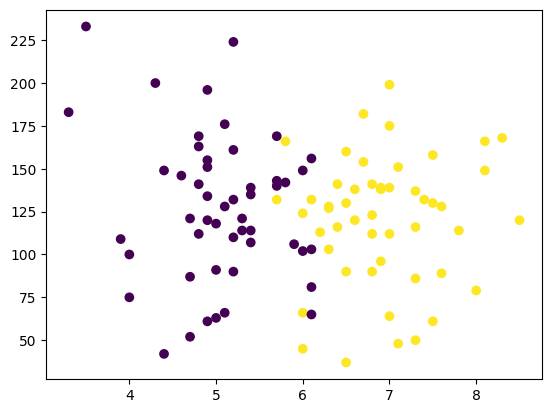

In [10]:
from matplotlib import colormaps
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

**Step 3:** Feature and Target Splitting

In [11]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

In [17]:
X.shape

(100, 2)

In [18]:
Y.shape

(100,)

**Step 4:** Train-Test Partitioning(`scikit-learn`)

In [19]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [23]:
X_train.shape, X_test.shape

((80, 2), (20, 2))

In [24]:
Y_train.shape, Y_test.shape

((80,), (20,))

**Step 5:** Standardization (`StandardScaler`)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
X_train_scaled[0:5]

array([[ 1.073416  ,  0.32804601],
       [ 0.89816441,  0.67630339],
       [ 0.63528702, -0.29384216],
       [-0.32859673,  1.12406287],
       [-0.9419773 , -1.51274298]])

**Step 6:** Model Training (`LogisticRegression`)

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
clf = LogisticRegression()

In [32]:
clf.fit(X_train_scaled, Y_train)

LogisticRegression()

In [33]:
clf.predict(X_test_scaled)

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [34]:
y_pred = clf.predict(X_test_scaled)

**Step 7:** Model Evaluation & Decision Boundary Plotting (`mlxtend`)

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
accuracy_score(Y_test, y_pred)

1.0

In [39]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

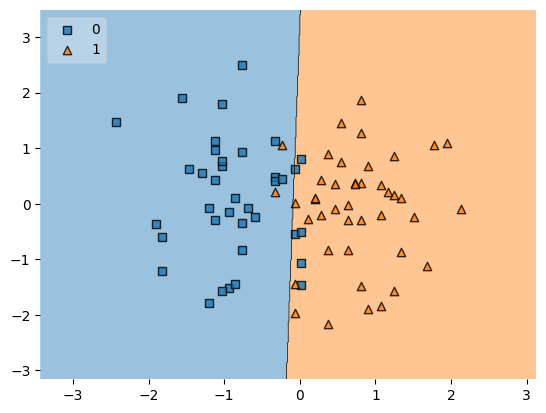

In [41]:
plot_decision_regions(X_train_scaled, Y_train.values, clf=clf, legend=2)

**Step 8:** Serialization (`pickle`)

In [42]:
import pickle
pickle.dump(clf, open('model.pkl', 'wb'))